<a href="https://colab.research.google.com/github/isegura/tema4_plndeep/blob/main/crear_modelo_word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini laboratorio: introducción práctica a Word Embeddings

Con este laboratorio, vamos a aprender:

- entrenar un pequeño modelo de word embeddings.

- palabras que aparecen en contextos similares tienden a tener vectores similares,

- los embeddings permiten calcular similitud entre palabras,



In [ ]:
!pip -q install gensim

In [ ]:
# creamos un pequeño corpus
corpus = [
    "el gato duerme en la cama",
    "el perro duerme en la alfombra",
    "el gato come pescado",
    "el perro come carne",
    "el gato juega con la pelota",
    "el perro juega en el parque",
    "el coche corre por la carretera",
    "el camión circula por la autopista",
    "el coche tiene ruedas",
    "el camión transporta carga",
    "el médico trabaja en el hospital",
    "la enfermera trabaja en el hospital",
    "el doctor atiende pacientes",
    "la enfermera cuida pacientes"
]


Vamos a tokenizar cada oración. Aunque podríamo utilizar spacy o nltk, para este ejemplo bastará con usar split.

In [ ]:

sentences = [text.lower().split() for text in corpus]
sentences

[['el', 'gato', 'duerme', 'en', 'la', 'cama'],
 ['el', 'perro', 'duerme', 'en', 'la', 'alfombra'],
 ['el', 'gato', 'come', 'pescado'],
 ['el', 'perro', 'come', 'carne'],
 ['el', 'gato', 'juega', 'con', 'la', 'pelota'],
 ['el', 'perro', 'juega', 'en', 'el', 'parque'],
 ['el', 'coche', 'corre', 'por', 'la', 'carretera'],
 ['el', 'camión', 'circula', 'por', 'la', 'autopista'],
 ['el', 'coche', 'tiene', 'ruedas'],
 ['el', 'camión', 'transporta', 'carga'],
 ['el', 'médico', 'trabaja', 'en', 'el', 'hospital'],
 ['la', 'enfermera', 'trabaja', 'en', 'el', 'hospital'],
 ['el', 'doctor', 'atiende', 'pacientes'],
 ['la', 'enfermera', 'cuida', 'pacientes']]

## Entrenamos el modelo Word2Vec

Hay dos tipos de arquitecturas:
- **CBOW (Continuous Bag of Words)**: la red es entrenada para predecir la palabra  dado un contexto. Por ejemplo, dado el contexto "gato __ en la cama", la red debe aprender la palabra duerme.

gato ___ en la cama → predecir duerme

- **Skip-gram**: la red es entrenada para pedecir el contexto a partir de la palabra central. Por ejemplo, dada la palabra duerme, la red es entrenada para aprender su contexto: "gato, en"

duerme -> gato, en

El modelo CBOW es más rápido y es la mejor opción cuando tenemos un corpus grandes. Por el contrario, Skip-gram captura mejor palabras raras y es mejor cuando tenemos pequeños corpus.

In [ ]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=sentences,
    vector_size=20,     # dimensión de los word embeddings
    window=2,           # Tamaño del contexto: indica cuántas palabras alrededor se consideran contexto.
    min_count=1,        # Frecuencia mínima para que una palabra entre en el vocabulario.
    workers=2,          # Número de procesos paralelos usados para entrenar.
    sg=1,               # Tipo de arquitectura del modelo: 1 = skip-gram, 0 = CBOW
    epochs=300
)

print("Dimensión del embedding:", model.vector_size)
print("Tamaño del vocabulario:", len(model.wv))
print("Vocabulario:", model.wv.index_to_key)
print("Palabra: frequencia")
for word in model.wv.index_to_key:
    print(word, model.wv.get_vecattr(word, "count"))


Dimensión del embedding: 20
Tamaño del vocabulario: 34
Vocabulario: ['el', 'la', 'en', 'perro', 'gato', 'pacientes', 'enfermera', 'hospital', 'trabaja', 'camión', 'por', 'coche', 'juega', 'come', 'duerme', 'cuida', 'atiende', 'doctor', 'médico', 'carga', 'transporta', 'ruedas', 'tiene', 'autopista', 'circula', 'carretera', 'corre', 'parque', 'pelota', 'con', 'carne', 'pescado', 'alfombra', 'cama']
Palabra: frequencia
el 15
la 7
en 5
perro 3
gato 3
pacientes 2
enfermera 2
hospital 2
trabaja 2
camión 2
por 2
coche 2
juega 2
come 2
duerme 2
cuida 1
atiende 1
doctor 1
médico 1
carga 1
transporta 1
ruedas 1
tiene 1
autopista 1
circula 1
carretera 1
corre 1
parque 1
pelota 1
con 1
carne 1
pescado 1
alfombra 1
cama 1


*Podemos* ver el embedding de una palabra:

In [ ]:
model.wv["gato"]

array([-0.07264161, -0.00287022,  0.11198897,  0.00730835, -0.01703361,
       -0.02636162,  0.13057907,  0.10074142, -0.1588848 ,  0.04160731,
        0.08724964, -0.03859255,  0.03026556, -0.07552569,  0.0871789 ,
        0.01225141,  0.10018856, -0.01932762, -0.09114623, -0.0744775 ],
      dtype=float32)

Obtener las palabras más similares a una dada:

In [ ]:
model.wv.most_similar("gato", topn=5)

[('el', 0.9306995272636414),
 ('la', 0.917934238910675),
 ('corre', 0.8922662734985352),
 ('come', 0.8908519148826599),
 ('circula', 0.8878065943717957)]

In [ ]:
model.wv.most_similar("perro", topn=5)

[('la', 0.9288471937179565),
 ('en', 0.9253987073898315),
 ('el', 0.9165159463882446),
 ('por', 0.9124665856361389),
 ('camión', 0.8953543901443481)]

In [ ]:
model.wv.most_similar("hospital", topn=5)

[('come', 0.8522310853004456),
 ('enfermera', 0.819214940071106),
 ('el', 0.8129183053970337),
 ('coche', 0.8112905025482178),
 ('por', 0.7989223003387451)]

También permite comparar similitud entre palabras:

In [ ]:
pares = [
    ("gato", "perro"),
    ("gato", "coche"),
    ("médico", "enfermera"),
    ("coche", "camión"),
    ("perro", "hospital"),
    ("médico", "hospital")

]

for w1, w2 in pares:
    sim = model.wv.similarity(w1, w2)
    print(f"Similitud({w1}, {w2}) = {sim:.4f}")

Similitud(gato, perro) = 0.8661
Similitud(gato, coche) = 0.8580
Similitud(médico, enfermera) = 0.7667
Similitud(coche, camión) = 0.8928
Similitud(perro, hospital) = 0.7619
Similitud(médico, hospital) = 0.6810


¿Qué pares muestran más similitud?, ¿están semánticamente relacionados?

## Visualización

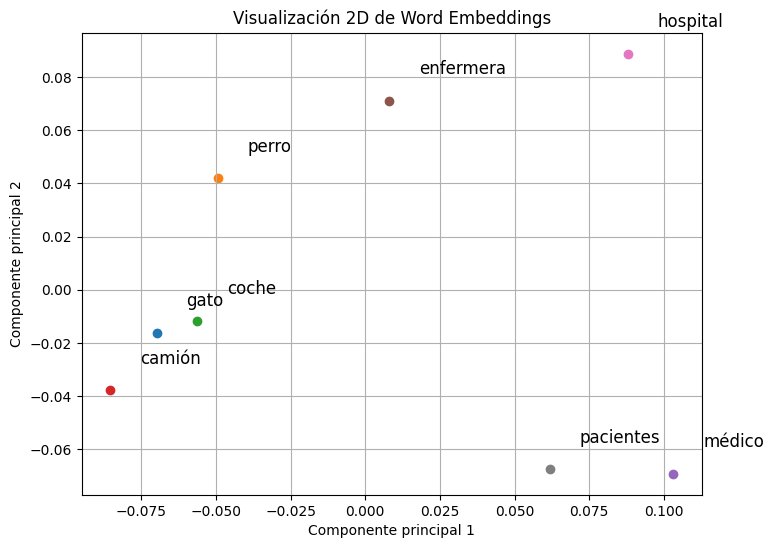

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words = ["gato", "perro", "coche", "camión", "médico", "enfermera", "hospital", "pacientes"]
vectors = [model.wv[w] for w in words]

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
for word, (x, y) in zip(words, coords):
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=12)

plt.title("Visualización 2D de Word Embeddings")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()

## Ejercicios:

### Ejercicio 1:

Añade nuevas frases al corpus, por ejemplo:

- el gato bebe leche
- el perro ladra fuerte
- el autobús circula por la ciudad
- el cirujano trabaja en el hospital

Vuelve a entrenar el modelo y responde:
- ¿Cambia la vecindad de gato?
- ¿autobús aparece cerca de coche o camión?
- ¿cirujano se acerca a médico?

### Ejercicio 2:
Cálcula estas similitudes:
- ("gato", "leche"),
- ("perro", "ladra"),
- ("autobús", "camión"),
- ("cirujano", "médico")

¿Tiene sentido el resultado según el corpus?

### Ejercicio 3:

Entrena un nuevo modelo, model2, donde cambies el tamaño de la ventana (4).

Luego compara las palabras más similares a gato con el primer modelo y con este segundo modelo.

## Conclusiones

1. Word2Vec aprende representaciones densas de palabras.
2. Las palabras con contextos similares tienden a tener embeddings similares.
3. Los embeddings permiten medir similitud semántica.
4. El corpus y los hiperparámetros influyen en el resultado.